### **Install libraries before running the code**
- pip install pandas
- pip install matplotlib
- pip install seaborn
- pip install scikit-learn

# **Main Code**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import os

data_dir = 'data'
path = [os.path.join(data_dir, f'xa{c}.dat') 
        for c in 'abcdefghi']

# merging the datasets
data_frames = [
    pd.read_csv(df, sep=r"\s+", header=None, engine="python")
    for df in path
]
vehicle_silhouettes= pd.concat(data_frames, ignore_index = True)

# asssigning names for the columns
column_names = [
    'compactness', 'circularity', 'distance circularity', 'radius ratio',
    'praxis aspect ratio', 'max length aspect ratio', 'scatter ratio' ,
    'elongatedness', 'praxis rectangularity', 'length rectangularity' ,
    'major variance', 'minor variance' , 'gyration radius' ,
    'major skewness' , 'minor skewness', 'minor kurtosis',
    'major kurtosis', 'hollows ratio', 'class'
]
vehicle_silhouettes.columns = column_names
pd.set_option('display.max_columns', None)

In [3]:
vehicle_silhouettes.to_csv('data.csv', index=False)

In [4]:
vehicle_silhouettes.head()

,compactness,circularity,distance circularity,radius ratio,praxis aspect ratio,max length aspect ratio,scatter ratio,elongatedness,praxis rectangularity,length rectangularity,major variance,minor variance,gyration radius,major skewness,minor skewness,minor kurtosis,major kurtosis,hollows ratio,class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


In [41]:
vehicle_silhouettes.shape

(846, 19)

In [5]:
vehicle_silhouettes.info()

<class 'pandas.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   compactness              846 non-null    int64
 1   circularity              846 non-null    int64
 2   distance circularity     846 non-null    int64
 3   radius ratio             846 non-null    int64
 4   praxis aspect ratio      846 non-null    int64
 5   max length aspect ratio  846 non-null    int64
 6   scatter ratio            846 non-null    int64
 7   elongatedness            846 non-null    int64
 8   praxis rectangularity    846 non-null    int64
 9   length rectangularity    846 non-null    int64
 10  major variance           846 non-null    int64
 11  minor variance           846 non-null    int64
 12  gyration radius          846 non-null    int64
 13  major skewness           846 non-null    int64
 14  minor skewness           846 non-null    int64
 15  minor kurtosis   

In [43]:
vehicle_silhouettes.isnull().sum()

compactness                0
circularity                0
distance circularity       0
radius ratio               0
praxis aspect ratio        0
max length aspect ratio    0
scatter ratio              0
elongatedness              0
praxis rectangularity      0
length rectangularity      0
major variance             0
minor variance             0
gyration radius            0
major skewness             0
minor skewness             0
minor kurtosis             0
major kurtosis             0
hollows ratio              0
class                      0
dtype: int64

In [44]:
vehicle_silhouettes['class'].value_counts()

class
bus     218
saab    217
opel    212
van     199
Name: count, dtype: int64

In [45]:
print(vehicle_silhouettes.duplicated().sum())

0


In [46]:
vehicle_silhouettes.columns

Index(['compactness', 'circularity', 'distance circularity', 'radius ratio',
       'praxis aspect ratio', 'max length aspect ratio', 'scatter ratio',
       'elongatedness', 'praxis rectangularity', 'length rectangularity',
       'major variance', 'minor variance', 'gyration radius', 'major skewness',
       'minor skewness', 'minor kurtosis', 'major kurtosis', 'hollows ratio',
       'class'],
      dtype='str')

In [47]:
from scipy.stats import zscore

z_score = vehicle_silhouettes.iloc[: , : -1].apply(zscore)  # Exclude 'class' column for numeric analysis
outliers = (z_score.abs() > 3).sum()

outliers

compactness                1
circularity                0
distance circularity       0
radius ratio               3
praxis aspect ratio        8
max length aspect ratio    9
scatter ratio              0
elongatedness              0
praxis rectangularity      1
length rectangularity      0
major variance             6
minor variance             4
gyration radius            0
major skewness             6
minor skewness             4
minor kurtosis             2
major kurtosis             0
hollows ratio              0
dtype: int64

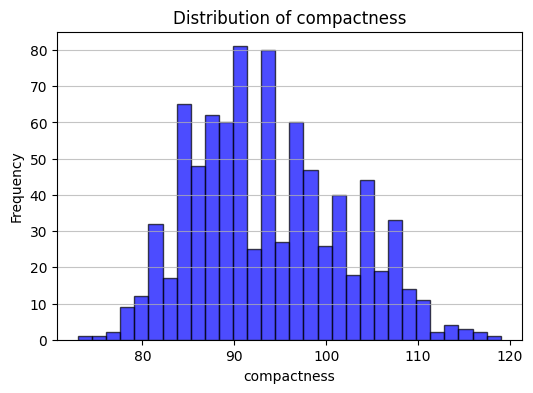

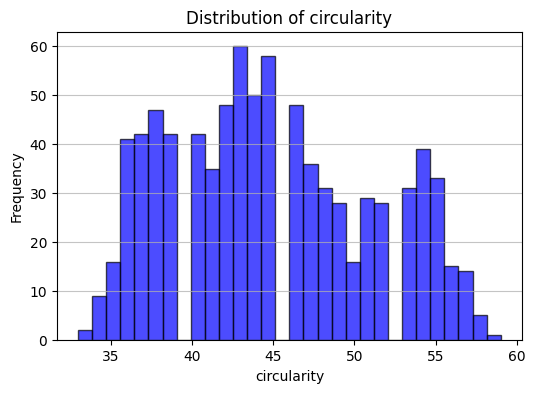

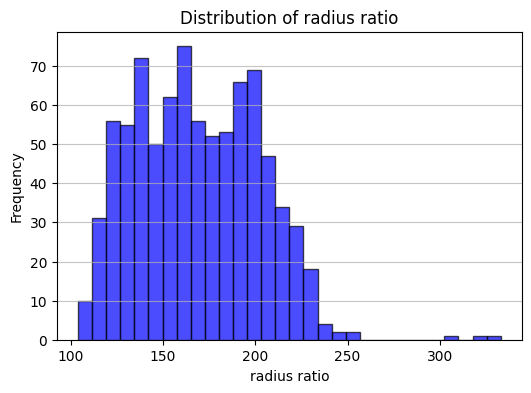

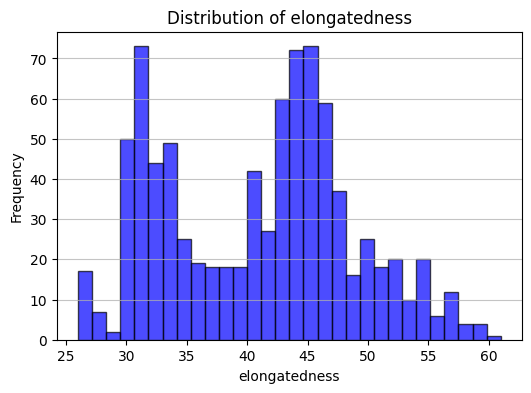

In [48]:
selected_features = ['compactness', 'circularity', 'radius ratio', 'elongatedness']

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    plt.hist(vehicle_silhouettes[feature], bins = 30, alpha = 0.7, color = 'blue', edgecolor = 'black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(axis = 'y', alpha = 0.75)
    plt.show()

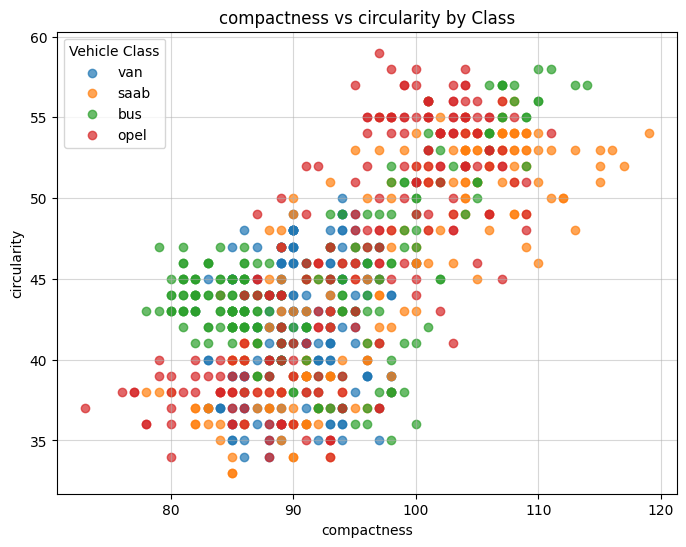

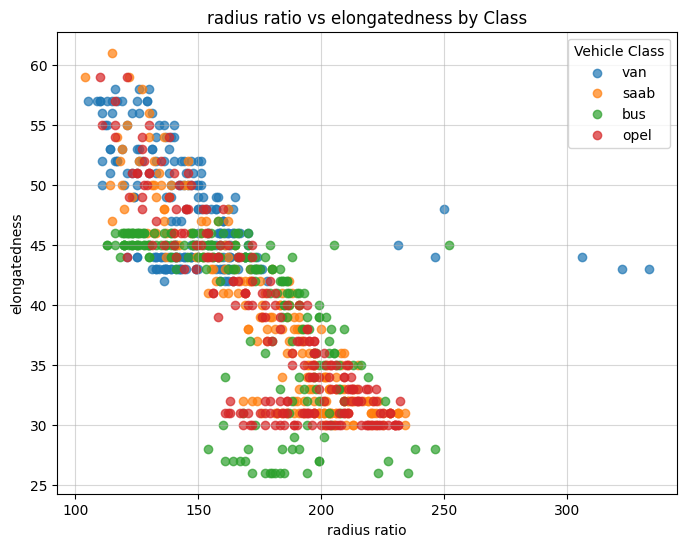

In [49]:
feature_pairs = [('compactness', 'circularity'), ('radius ratio', 'elongatedness')]
classes = vehicle_silhouettes['class'].unique()

for feature_x, feature_y in feature_pairs:
    plt.figure(figsize = (8, 6))
    for vehicle_class in classes:
        subset = vehicle_silhouettes[vehicle_silhouettes['class'] == vehicle_class]
        plt.scatter(subset[feature_x], subset[feature_y], label = vehicle_class, alpha = 0.7)
        
    plt.title(f'{feature_x} vs {feature_y} by Class')
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.legend(title='Vehicle Class')
    plt.grid(alpha=0.5)
    plt.show()

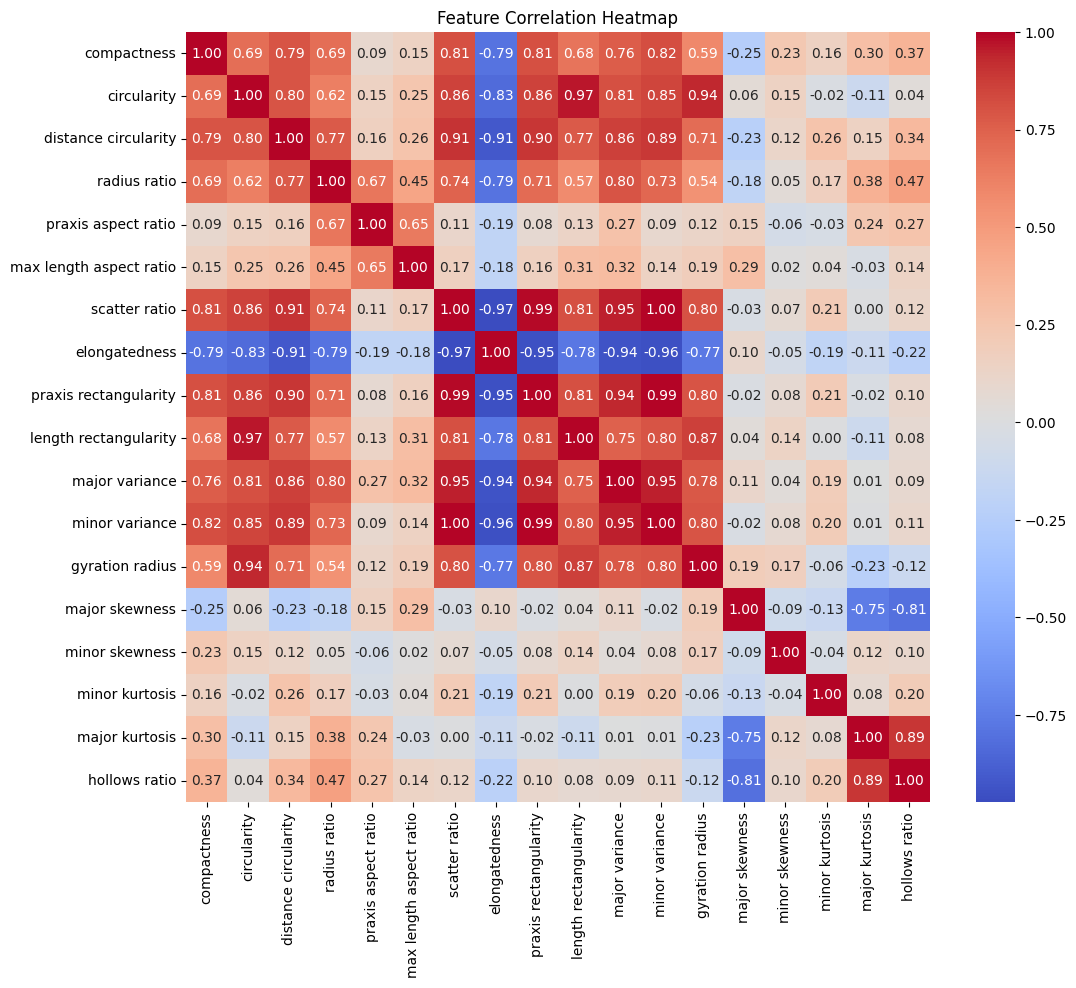

In [50]:
correlation_matrix = vehicle_silhouettes.drop(columns=['class']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Heatmap')
plt.show()

In [51]:
vehicle_silhouettes.columns

Index(['compactness', 'circularity', 'distance circularity', 'radius ratio',
       'praxis aspect ratio', 'max length aspect ratio', 'scatter ratio',
       'elongatedness', 'praxis rectangularity', 'length rectangularity',
       'major variance', 'minor variance', 'gyration radius', 'major skewness',
       'minor skewness', 'minor kurtosis', 'major kurtosis', 'hollows ratio',
       'class'],
      dtype='str')

In [52]:
vehicle_silhouettes['class'].value_counts()

class
bus     218
saab    217
opel    212
van     199
Name: count, dtype: int64

In [53]:
# using label encoder
le = LabelEncoder()
vehicle_silhouettes['edited_class'] = le.fit_transform(vehicle_silhouettes['class'])

labeles = dict (zip (le.classes_, range(len(le.classes_))))

labeles

{'bus': 0, 'opel': 1, 'saab': 2, 'van': 3}

In [54]:
vehicle_silhouettes[['class', 'edited_class']].head()

,class,edited_class
0,van,3
1,van,3
2,saab,2
3,van,3
4,bus,0


In [55]:
# numeric columns 
numeric_columns = vehicle_silhouettes.drop(columns = ['class','edited_class']) 

# data
data = pd.DataFrame(numeric_columns , columns = numeric_columns.columns)
data ['edited_class'] = vehicle_silhouettes ['edited_class']

scaler = StandardScaler()
scaled = scaler.fit_transform(numeric_columns)

# scaled data
scaled_data = pd.DataFrame(scaled, columns=numeric_columns.columns)

scaled_data['edited_class']= vehicle_silhouettes['edited_class']

In [56]:
scaled_data.head()

,compactness,circularity,distance circularity,radius ratio,praxis aspect ratio,max length aspect ratio,scatter ratio,elongatedness,praxis rectangularity,length rectangularity,major variance,minor variance,gyration radius,major skewness,minor skewness,minor kurtosis,major kurtosis,hollows ratio,edited_class
0,0.160580,0.508950,0.057819,0.270806,1.307291,0.311542,-0.205844,0.136570,-0.224944,0.758332,-0.402383,-0.344935,0.285812,-0.329056,-0.076711,0.380991,-0.313722,0.183957,3
1,-0.325470,-0.626268,0.121261,-0.835244,-0.595396,0.094079,-0.597112,0.520843,-0.610954,-0.344578,-0.593611,-0.622416,-0.513517,-0.061767,0.533610,0.156925,0.010937,0.452977,3
2,1.254193,0.833298,1.517005,1.197496,0.546217,0.311542,1.148544,-1.144341,0.933086,0.689401,1.095564,1.104766,1.392577,0.071877,1.550812,-0.403238,-0.151393,0.049447,2
3,-0.082445,-0.626268,-0.005624,-0.297166,0.165679,0.094079,-0.747600,0.648935,-0.610954,-0.344578,-0.912323,-0.741337,-1.466565,-1.264566,-0.076711,-0.291206,1.634233,1.529056,3
4,-1.054545,-0.139746,-0.766939,1.077923,5.239511,9.444962,-0.597112,0.520843,-0.610954,-0.275646,1.669245,-0.650731,0.408786,7.288670,0.533610,-0.179173,-1.450029,-1.699181,0


In [57]:
data.head()

,compactness,circularity,distance circularity,radius ratio,praxis aspect ratio,max length aspect ratio,scatter ratio,elongatedness,praxis rectangularity,length rectangularity,major variance,minor variance,gyration radius,major skewness,minor skewness,minor kurtosis,major kurtosis,hollows ratio,edited_class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,3
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,3
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,2
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,3
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,0


In [58]:
# splitting the data
x = data.drop(columns = ['edited_class'])
y = data['edited_class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# the shapes after the split
print('x_training shape ' , x_train.shape)
print('x_testing shape ' , x_test.shape)
print('y_training shape:', y_train.shape)
print('y_testing shape:', y_test.shape)

x_training shape  (676, 18)
x_testing shape  (170, 18)
y_training shape: (676,)
y_testing shape: (170,)


In [59]:
# scaling data
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform(x_test)

print('scaled_x_train shape: ' , x_train.shape)
print('scaled_x_test shape: ' , x_test.shape)
print('scaled_y_train shape: ', y_train.shape)
print('scaled_y_test shape: ', y_test.shape)

scaled_x_train shape:  (676, 18)
scaled_x_test shape:  (170, 18)
scaled_y_train shape:  (676,)
scaled_y_test shape:  (170,)


In [60]:
# LR
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# training
lr = LogisticRegression(solver = 'lbfgs', random_state = 42 , C = 10)
lr.fit(scaled_x_train, y_train)

# making predictions
y_prediction_test = lr.predict(scaled_x_test)

print('lr performance: ')
print(classification_report(y_test, y_prediction_test))
print('confusion natrix:')
print(confusion_matrix(y_test, y_prediction_test))

lr performance: 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1       0.75      0.57      0.65        42
           2       0.69      0.84      0.76        44
           3       0.95      0.97      0.96        40

    accuracy                           0.84       170
   macro avg       0.85      0.84      0.84       170
weighted avg       0.85      0.84      0.84       170

confusion natrix:
[[43  1  0  0]
 [ 0 24 16  2]
 [ 0  7 37  0]
 [ 0  0  1 39]]


c:\Users\volca\Desktop\VSCode\Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [61]:
parameter_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(LogisticRegression(solver = 'lbfgs', random_state = 42), parameter_grid_lr, cv = 5)
grid_lr.fit(scaled_x_train, y_train)

print('best parameters for LR:', grid_lr.best_params_)
print('best score:', grid_lr.best_score_)

c:\Users\volca\Desktop\VSCode\Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\volca\Desktop\VSCode\Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/m

best parameters for LR: {'C': 100}
best score: 0.7928758169934641


c:\Users\volca\Desktop\VSCode\Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\volca\Desktop\VSCode\Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/m

In [62]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

# training
knn = KNeighborsClassifier(metric = 'euclidean', n_neighbors = 9, weights = 'distance')
knn.fit(scaled_x_train, y_train)

# making predictions
y_pred_knn = knn.predict(scaled_x_test)

print('confusion matrix: ')
print(confusion_matrix(y_test, y_pred_knn))

print('KNN performance: ')
print(classification_report(y_test, y_pred_knn))

confusion matrix: 
[[43  1  0  0]
 [ 2 17 18  5]
 [ 0 16 27  1]
 [ 2  0  3 35]]
KNN performance: 
              precision    recall  f1-score   support

           0       0.91      0.98      0.95        44
           1       0.50      0.40      0.45        42
           2       0.56      0.61      0.59        44
           3       0.85      0.88      0.86        40

    accuracy                           0.72       170
   macro avg       0.71      0.72      0.71       170
weighted avg       0.71      0.72      0.71       170



In [63]:
parameter_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), parameter_grid_knn, cv = 5, scoring = 'accuracy')
grid_knn.fit(scaled_x_train, y_train)

print('best parameters for knn: ', grid_knn.best_params_)
print('best accuracy:', grid_knn.best_score_)

best parameters for knn:  {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
best accuracy: 0.7160130718954247


In [64]:
# SVM
from sklearn.svm import SVC

# training
svm = SVC(probability=True, random_state = 42 , C = 100, gamma = 'scale', kernel = 'rbf')
svm.fit(scaled_x_train, y_train)

# making predictions
y_pred_svm = svm.predict(scaled_x_test)

print('SVM performance:')
print(classification_report(y_test, y_pred_svm))

print('confusion matrix: ')
print(confusion_matrix(y_test, y_pred_svm))

SVM performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.76      0.67      0.71        42
           2       0.73      0.82      0.77        44
           3       0.95      0.95      0.95        40

    accuracy                           0.86       170
   macro avg       0.86      0.86      0.86       170
weighted avg       0.86      0.86      0.86       170

confusion matrix: 
[[44  0  0  0]
 [ 0 28 12  2]
 [ 0  8 36  0]
 [ 0  1  1 38]]


In [65]:
parameter_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(random_state = 42), parameter_grid_svm, cv = 5 , scoring = 'accuracy')
grid_svm.fit(scaled_x_train, y_train)

print('best parameters for SVM:', grid_svm.best_params_)
print('best accuracy:', grid_svm.best_score_)

best parameters for SVM: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
best accuracy: 0.8283769063180829


In [66]:
# DT
from sklearn.tree import DecisionTreeClassifier

# training
dt = DecisionTreeClassifier(random_state = 42,criterion = 'entropy', max_depth = None, min_samples_leaf = 1, min_samples_split = 5)
dt.fit(x_train, y_train)

# making predictions
y_pred_tree = dt.predict(x_test)

print("dt performance: ")
print(classification_report(y_test, y_pred_tree))

print("confusion matrix:")
print(confusion_matrix(y_test, y_pred_tree))

dt performance: 
              precision    recall  f1-score   support

           0       0.91      0.98      0.95        44
           1       0.53      0.57      0.55        42
           2       0.54      0.50      0.52        44
           3       0.89      0.82      0.86        40

    accuracy                           0.72       170
   macro avg       0.72      0.72      0.72       170
weighted avg       0.72      0.72      0.72       170

confusion matrix:
[[43  1  0  0]
 [ 1 24 15  2]
 [ 1 19 22  2]
 [ 2  1  4 33]]


In [67]:
parameter_grid_dt = {
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state = 42), parameter_grid_dt, cv = 5, scoring= 'accuracy')
grid_tree.fit(x_train, y_train)

print("best parameters for dt:", grid_tree.best_params_)
print("best accuracy:", grid_tree.best_score_)

best parameters for dt: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
best accuracy: 0.7174400871459694


In [68]:
# RF
from sklearn.ensemble import RandomForestClassifier

# training
rf = RandomForestClassifier(random_state = 42 , criterion = 'gini', max_depth = None, min_samples_leaf = 1, min_samples_split = 5, n_estimators = 50)
rf.fit(x_train, y_train)

# making predections
y_pred_forest = rf.predict(x_test)

print("rf performance: ")
print(classification_report(y_test, y_pred_forest))

print("confusion matrix:")
print(confusion_matrix(y_test, y_pred_forest))

rf performance: 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        44
           1       0.58      0.43      0.49        42
           2       0.55      0.61      0.58        44
           3       0.91      0.97      0.94        40

    accuracy                           0.75       170
   macro avg       0.74      0.75      0.75       170
weighted avg       0.74      0.75      0.74       170

confusion matrix:
[[44  0  0  0]
 [ 1 18 21  2]
 [ 2 13 27  2]
 [ 0  0  1 39]]


In [ ]:
parameter_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}


grid_rf = GridSearchCV(RandomForestClassifier(random_state = 42) , parameter_grid_rf, cv = 5, scoring = 'accuracy')
grid_rf.fit(x_train, y_train)

print('best parameters for rf:', grid_rf.best_params_)
print('best accuracy:' , grid_rf.best_score_)

best parameters for rf: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
best accuracy: 0.7647930283224401


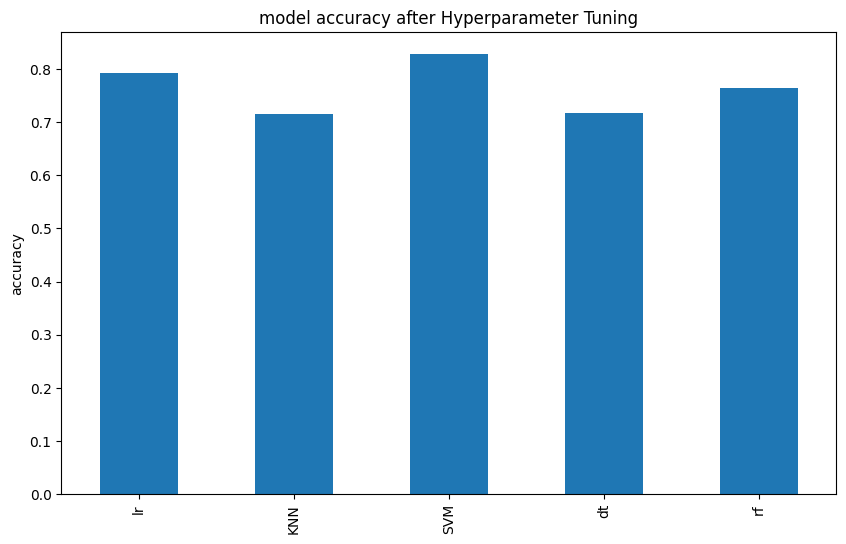

In [ ]:
results = {
    'lr': [grid_lr.best_score_],
    'KNN': [grid_knn.best_score_],
    'SVM': [grid_svm.best_score_],
    'dt': [grid_tree.best_score_],
    'rf': [grid_rf.best_score_],
}

result_df = pd.DataFrame(results, index = ['accuracy']).T
result_df.plot(kind='bar', figsize = (10, 6), legend = False)

plt.title('model accuracy after Hyperparameter Tuning')
plt.ylabel('accuracy')
plt.show()

### **IMPORTANT**

This dataset comes from the Turing Institute, Glasgow, Scotland. 

### **SOURCE**

Drs.Pete Mowforth and Barry Shepherd
Turing Institute
George House
36 North Hanover St.
Glasgow
G1 2AD
